# Problem 4 - Grover Search with Dynamic MCZ

This notebook builds and runs Grover search using a measurement-uncompute multi-controlled Z (MCZ). It contains only the MCZ implementation needed by Grover, the phase oracle, the diffuser, and a runnable experiment.

For `k >= 3`, the dynamic MCZ computes a balanced AND tree, applies `Z` to its root, and removes the work ancillas using X-basis measurements and conditional CZ corrections.

In [23]:
from __future__ import annotations

import math
from typing import Iterable

import pandas as pd
from IPython.display import display

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.result import marginal_counts
from qiskit_aer import AerSimulator

SEED = 1234
DEFAULT_SHOTS = 1024

print("Dynamic-MCZ Grover setup ready.")

Dynamic-MCZ Grover setup ready.


## Dynamic MCZ

Leaves of the balanced AND tree are the data qubits. Internal nodes use `k - 1` work ancillas. After the root phase is applied, each work qubit is measured in the X basis and its measurement result controls a CZ correction on its two inputs.

In [24]:
def validate_num_controls(num_controls: int) -> int:
    num_controls = int(num_controls)
    if num_controls < 1:
        raise ValueError("num_controls must be at least 1.")
    return num_controls


def mcz_ancilla_count(num_controls: int) -> int:
    """Number of balanced-AND-tree work ancillas."""
    num_controls = validate_num_controls(num_controls)
    return 0 if num_controls <= 2 else num_controls - 1


def balanced_and_tree(num_controls: int) -> dict:
    """Return bottom-up AND-tree levels in a logical qubit index space."""
    num_controls = validate_num_controls(num_controls)
    if num_controls <= 2:
        return {
            "levels": [],
            "root": 0 if num_controls == 1 else None,
            "ancilla_count": 0,
        }

    levels = []
    next_ancilla = 0
    current = list(range(num_controls))

    while len(current) > 1:
        level = []
        next_nodes = []
        index = 0

        while index < len(current):
            left = current[index]
            if index + 1 == len(current):
                next_nodes.append(left)
                index += 1
                continue

            right = current[index + 1]
            target = num_controls + next_ancilla
            next_ancilla += 1
            level.append((left, right, target))
            next_nodes.append(target)
            index += 2

        levels.append(level)
        current = next_nodes

    return {
        "levels": levels,
        "root": current[0],
        "ancilla_count": next_ancilla,
    }


def _as_list(register_or_qubits) -> list:
    return list(register_or_qubits) if register_or_qubits is not None else []


def apply_dynamic_mcz(
    qc: QuantumCircuit,
    controls,
    ancillas=None,
    measure_bits=None,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply MCZ using forward AND computation and measurement-uncompute."""
    controls = _as_list(controls)
    ancillas = _as_list(ancillas)
    measure_bits = _as_list(measure_bits)
    num_controls = validate_num_controls(len(controls))

    if num_controls == 1:
        qc.z(controls[0])
        return qc
    if num_controls == 2:
        qc.cz(controls[0], controls[1])
        return qc

    tree = balanced_and_tree(num_controls)
    expected_ancillas = tree["ancilla_count"]
    if len(ancillas) != expected_ancillas:
        raise ValueError(
            f"Expected {expected_ancillas} ancillas, got {len(ancillas)}."
        )
    if len(measure_bits) != expected_ancillas:
        raise ValueError(
            f"Expected {expected_ancillas} measurement bits, got {len(measure_bits)}."
        )

    qubit_map = controls + ancillas

    for level in tree["levels"]:
        for left, right, target in level:
            qc.ccx(qubit_map[left], qubit_map[right], qubit_map[target])

    if add_barriers:
        qc.barrier()
    qc.z(qubit_map[tree["root"]])
    if add_barriers:
        qc.barrier()

    bit_index = 0
    for level in reversed(tree["levels"]):
        measured_nodes = []

        for left, right, target in level:
            bit = measure_bits[bit_index]
            qc.h(qubit_map[target])
            qc.measure(qubit_map[target], bit)
            measured_nodes.append((left, right, bit))
            bit_index += 1

        for left, right, bit in measured_nodes:
            with qc.if_test((bit, 1)):
                qc.cz(qubit_map[left], qubit_map[right])

        if add_barriers:
            qc.barrier()

    return qc

## Unitary and Dynamic MCZ Circuit Diagrams

The unitary MCZ computes and reverses the AND tree. The dynamic MCZ replaces the reverse tree with X-basis measurements and conditional CZ corrections. Change `MCZ_DIAGRAM_QUBITS` to draw a different MCZ size.

In [25]:
def apply_unitary_mcz(
    qc: QuantumCircuit,
    controls,
    ancillas=None,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply a clean unitary MCZ using a reversible AND tree."""
    controls = _as_list(controls)
    ancillas = _as_list(ancillas)
    num_controls = validate_num_controls(len(controls))

    if num_controls == 1:
        qc.z(controls[0])
        return qc
    if num_controls == 2:
        qc.cz(controls[0], controls[1])
        return qc

    tree = balanced_and_tree(num_controls)
    expected_ancillas = tree["ancilla_count"]
    if len(ancillas) != expected_ancillas:
        raise ValueError(
            f"Expected {expected_ancillas} ancillas, got {len(ancillas)}."
        )

    qubit_map = controls + ancillas
    for level in tree["levels"]:
        for left, right, target in level:
            qc.ccx(qubit_map[left], qubit_map[right], qubit_map[target])

    if add_barriers:
        qc.barrier()
    qc.z(qubit_map[tree["root"]])
    if add_barriers:
        qc.barrier()

    for level in reversed(tree["levels"]):
        for left, right, target in reversed(level):
            qc.ccx(qubit_map[left], qubit_map[right], qubit_map[target])

    return qc


def build_unitary_mcz(
    num_controls: int,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build a standalone unitary MCZ circuit."""
    num_controls = validate_num_controls(num_controls)
    ancilla_count = mcz_ancilla_count(num_controls)
    data = QuantumRegister(num_controls, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    registers = [data] + ([anc] if anc is not None else [])
    qc = QuantumCircuit(*registers, name=f"unitary_mcz_{num_controls}")
    apply_unitary_mcz(qc, data, anc or [], add_barriers=add_barriers)
    return qc


def build_dynamic_mcz(
    num_controls: int,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build a standalone measurement-uncompute MCZ circuit."""
    num_controls = validate_num_controls(num_controls)
    ancilla_count = mcz_ancilla_count(num_controls)
    data = QuantumRegister(num_controls, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    mu = ClassicalRegister(ancilla_count, "mu") if ancilla_count else None
    registers = (
        [data]
        + ([anc] if anc is not None else [])
        + ([mu] if mu is not None else [])
    )
    qc = QuantumCircuit(*registers, name=f"dynamic_mcz_{num_controls}")
    apply_dynamic_mcz(
        qc,
        data,
        anc or [],
        mu or [],
        add_barriers=add_barriers,
    )
    return qc

Unitary MCZ (4 data qubits)


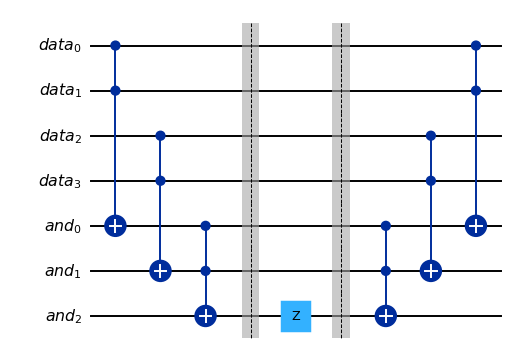

Dynamic MCZ (4 data qubits)


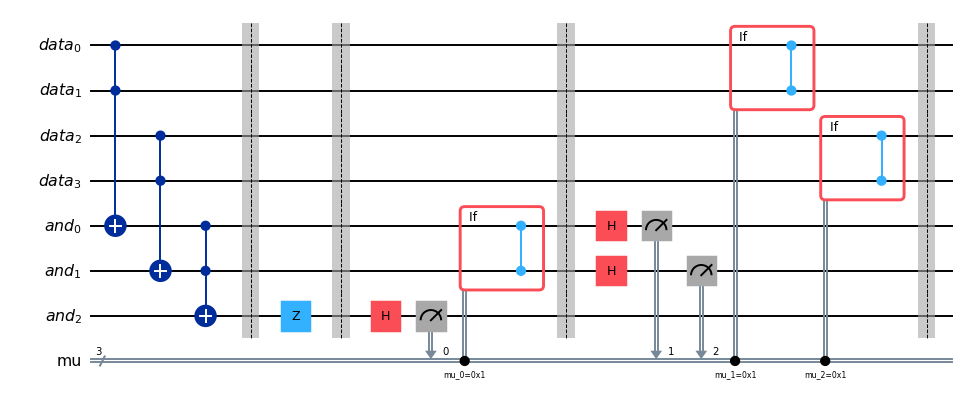

In [26]:
MCZ_DIAGRAM_QUBITS = 4

unitary_mcz_circuit = build_unitary_mcz(MCZ_DIAGRAM_QUBITS)
dynamic_mcz_circuit = build_dynamic_mcz(MCZ_DIAGRAM_QUBITS)

print(f"Unitary MCZ ({MCZ_DIAGRAM_QUBITS} data qubits)")
display(
    unitary_mcz_circuit.draw(
        "mpl", fold=-1, scale=0.7, idle_wires=False
    )
)

print(f"Dynamic MCZ ({MCZ_DIAGRAM_QUBITS} data qubits)")
display(
    dynamic_mcz_circuit.draw(
        "mpl", fold=-1, scale=0.7, idle_wires=False
    )
)

## Grover Phase Oracle

For each marked state, `X` gates turn its zero bits into open controls, and the dynamic MCZ flips only that state's phase. Qiskit displays bit strings as `q[n-1]...q[0]`, so the target string is reversed when it is mapped to data-qubit indices.

Measurement-uncompute disentangles the work ancillas but does not necessarily leave them in `|0>`. The oracle therefore resets the workspace after each MCZ before it is reused.

In [27]:
def _normalize_marked_states(marked_states: str | Iterable[str]) -> list[str]:
    """Validate marked states and remove duplicate strings."""
    if isinstance(marked_states, str):
        marked_states = [marked_states]
    else:
        marked_states = list(marked_states)

    if not marked_states:
        raise ValueError("marked_states must contain at least one bit string.")
    if any(not isinstance(state, str) or not state for state in marked_states):
        raise ValueError("Every marked state must be a non-empty bit string.")

    num_qubits = len(marked_states[0])
    if any(len(state) != num_qubits for state in marked_states):
        raise ValueError("All marked states must have the same number of bits.")
    if any(set(state) - {"0", "1"} for state in marked_states):
        raise ValueError("Marked states may contain only '0' and '1'.")

    return list(dict.fromkeys(marked_states))


def apply_dynamic_grover_oracle(
    qc: QuantumCircuit,
    data,
    ancillas,
    measure_bits,
    marked_states: str | Iterable[str],
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply a multi-target Grover phase oracle using the dynamic MCZ."""
    marked_states = _normalize_marked_states(marked_states)
    data = _as_list(data)
    ancillas = _as_list(ancillas)
    measure_bits = _as_list(measure_bits)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    if len(data) != num_qubits:
        raise ValueError(f"Expected {num_qubits} data qubits, got {len(data)}.")
    if len(ancillas) != ancilla_count:
        raise ValueError(f"Expected {ancilla_count} ancillas, got {len(ancillas)}.")
    if len(measure_bits) != ancilla_count:
        raise ValueError(
            f"Expected {ancilla_count} measurement bits, got {len(measure_bits)}."
        )

    for target in marked_states:
        zero_indices = [
            index for index, bit in enumerate(target[::-1]) if bit == "0"
        ]

        if zero_indices:
            qc.x([data[index] for index in zero_indices])

        apply_dynamic_mcz(
            qc,
            data,
            ancillas,
            measure_bits,
            add_barriers=add_barriers,
        )

        if zero_indices:
            qc.x([data[index] for index in zero_indices])
        if ancillas:
            qc.reset(ancillas)
        if add_barriers:
            qc.barrier(*data)

    return qc


def grover_oracle(
    marked_states: str | Iterable[str],
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Build a standalone dynamic-circuit Grover phase oracle."""
    marked_states = _normalize_marked_states(marked_states)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    data = QuantumRegister(num_qubits, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    mu = ClassicalRegister(ancilla_count, "mu") if ancilla_count else None
    registers = (
        [data]
        + ([anc] if anc is not None else [])
        + ([mu] if mu is not None else [])
    )
    qc = QuantumCircuit(*registers, name="dynamic_grover_oracle")

    apply_dynamic_grover_oracle(
        qc,
        data,
        anc or [],
        mu or [],
        marked_states,
        add_barriers=add_barriers,
    )
    qc.metadata = {
        "block": "grover_oracle",
        "implementation": "dynamic_mcz",
        "marked_states": marked_states,
        "num_data_qubits": num_qubits,
        "ancilla_count": ancilla_count,
    }
    return qc

## Complete Grover Circuit

The diffuser is `H^n X^n MCZ X^n H^n` and uses the same dynamic MCZ workspace. If `iterations=None`, the circuit chooses the nearest integer to `pi/(4 theta) - 1/2`, with `theta = asin(sqrt(M/N))`.

In [28]:
def apply_dynamic_grover_diffuser(
    qc: QuantumCircuit,
    data,
    ancillas,
    measure_bits,
    add_barriers: bool = True,
) -> QuantumCircuit:
    """Apply the Grover diffuser using the dynamic MCZ."""
    data = _as_list(data)
    ancillas = _as_list(ancillas)
    measure_bits = _as_list(measure_bits)

    qc.h(data)
    qc.x(data)
    apply_dynamic_mcz(
        qc,
        data,
        ancillas,
        measure_bits,
        add_barriers=add_barriers,
    )
    if ancillas:
        qc.reset(ancillas)
    qc.x(data)
    qc.h(data)

    if add_barriers:
        qc.barrier(*data)
    return qc


def optimal_grover_iterations(num_qubits: int, num_marked: int) -> int:
    """Return a near-optimal integer number of Grover iterations."""
    num_qubits = validate_num_controls(num_qubits)
    search_space_size = 2**num_qubits
    if not 1 <= num_marked <= search_space_size:
        raise ValueError("num_marked must be between 1 and 2**num_qubits.")

    theta = math.asin(math.sqrt(num_marked / search_space_size))
    real_iterations = math.pi / (4 * theta) - 0.5
    return max(0, math.floor(real_iterations + 0.5))


def build_dynamic_grover_circuit(
    marked_states: str | Iterable[str],
    iterations: int | None = None,
    add_barriers: bool = True,
    measure: bool = True,
) -> QuantumCircuit:
    """Build Grover search with dynamic-MCZ oracle and diffuser blocks."""
    marked_states = _normalize_marked_states(marked_states)
    num_qubits = len(marked_states[0])
    ancilla_count = mcz_ancilla_count(num_qubits)

    if iterations is None:
        iterations = optimal_grover_iterations(num_qubits, len(marked_states))
    if not isinstance(iterations, int) or iterations < 0:
        raise ValueError("iterations must be a non-negative integer.")

    data = QuantumRegister(num_qubits, "data")
    anc = QuantumRegister(ancilla_count, "and") if ancilla_count else None
    mu = ClassicalRegister(ancilla_count, "mu") if ancilla_count else None
    out = ClassicalRegister(num_qubits, "out") if measure else None
    registers = (
        [data]
        + ([anc] if anc is not None else [])
        + ([mu] if mu is not None else [])
        + ([out] if out is not None else [])
    )
    qc = QuantumCircuit(*registers, name="dynamic_grover")

    qc.h(data)
    if add_barriers:
        qc.barrier(*data)

    for _ in range(iterations):
        apply_dynamic_grover_oracle(
            qc,
            data,
            anc or [],
            mu or [],
            marked_states,
            add_barriers=add_barriers,
        )
        apply_dynamic_grover_diffuser(
            qc,
            data,
            anc or [],
            mu or [],
            add_barriers=add_barriers,
        )

    if measure:
        qc.measure(data, out)

    qc.metadata = {
        "algorithm": "grover",
        "implementation": "dynamic_mcz",
        "marked_states": marked_states,
        "iterations": iterations,
        "num_data_qubits": num_qubits,
        "ancilla_count": ancilla_count,
    }
    return qc


def register_counts(counts: dict, circuit: QuantumCircuit, register_name: str) -> dict:
    """Return counts marginalized to one named classical register."""
    register = next(
        (creg for creg in circuit.cregs if creg.name == register_name),
        None,
    )
    if register is None:
        raise ValueError(f"No classical register named {register_name!r}.")

    indices = [circuit.clbits.index(bit) for bit in register]
    return dict(marginal_counts(counts, indices=indices))

## Run the Grover Experiment

Change `GROVER_MARKED_STATES` to one bit string or a list of bit strings. All strings must have the same length.

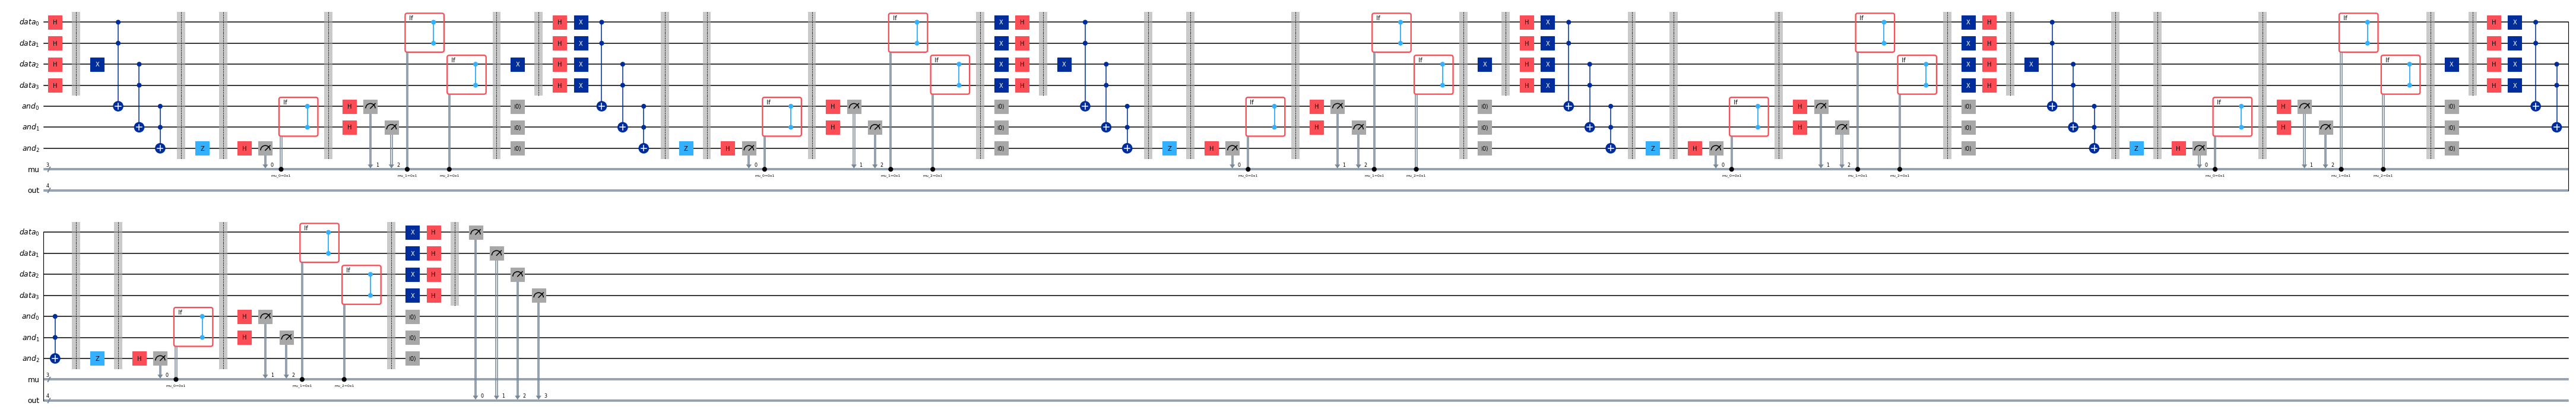

,counts
1011,981
1000,6
1111,5
0101,4
0110,4
0111,4
0010,3
1010,3
0011,3
0001,3


iterations: 3
marked-state success probability: 0.9580078125


In [29]:
GROVER_MARKED_STATES = ["1011"]
GROVER_ITERATIONS = None  # None selects a near-optimal value automatically.
GROVER_SHOTS = DEFAULT_SHOTS

grover_circuit = build_dynamic_grover_circuit(
    GROVER_MARKED_STATES,
    iterations=GROVER_ITERATIONS,
    add_barriers=True,
)
display(grover_circuit.draw("mpl", fold=120, scale=0.55, idle_wires=False))

simulator = AerSimulator(
    method="matrix_product_state",
    seed_simulator=SEED,
)
result = simulator.run(
    grover_circuit,
    shots=GROVER_SHOTS,
    seed_simulator=SEED,
).result()

raw_counts = result.get_counts(0)
grover_counts = register_counts(raw_counts, grover_circuit, "out")
success_probability = sum(
    grover_counts.get(state, 0) for state in GROVER_MARKED_STATES
) / sum(grover_counts.values())

display(
    pd.DataFrame({"counts": pd.Series(grover_counts)})
    .sort_values("counts", ascending=False)
)
print("iterations:", grover_circuit.metadata["iterations"])
print("marked-state success probability:", success_probability)